In [14]:
# ============================================================
# ⚙️ Configuration & Imports
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# -------------------------
# Configurable paths
# -------------------------


DATA_FILE = "../0. Datasets/patients_structured_numeric.csv"  # <— central data config
MODEL_PATH = "../4. Models/ diabetes_model.pkl"

pd.set_option("display.max_columns", None)


In [15]:
# ============================================================
# 📂 Load dataset
# ============================================================

import os

if not os.path.exists(DATA_FILE):
    DATA_FILE = f"../{DATA_FILE}"

df = pd.read_csv(DATA_FILE)
print(f"✅ Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())


✅ Loaded dataset with 2400 rows and 10 columns


,patient_id,has_diabetes,Age,Gender,Hypertension,Heart Disease,Smoking History,BMI,HbA1c,Random Glucose
0,82555,0.0,16.0,1.0,0.0,0.0,0,21.49,6.2,100.0
1,92299,0.0,15.0,1.0,0.0,0.0,0,33.62,5.3,158.0
2,18725,0.0,54.0,0.0,0.0,0.0,2,21.46,5.3,145.0
3,52208,1.0,54.0,1.0,0.0,0.0,0,39.12,6.8,160.0
4,2640,0.0,29.0,1.0,0.0,0.0,1,38.25,3.5,126.0


In [16]:
# ============================================================
# 🧹 Data preprocessing
# ============================================================

expected_cols = [
    "patient_id", "has_diabetes", "Age", "Gender",
    "Hypertension", "Heart Disease", "Smoking History",
    "BMI", "HbA1c", "Random Glucose"
]
df = df[[c for c in expected_cols if c in df.columns]].dropna()

# Separate features & target
X = df.drop(columns=["patient_id", "has_diabetes"])
y = df["has_diabetes"].astype(int)

print("✅ Cleaned and ready for model training")


✅ Cleaned and ready for model training


In [17]:
# ============================================================
# 🧠 Train/Test Split (Detailed)
# ============================================================

from sklearn.model_selection import train_test_split

# --- Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,
    stratify=y            # keeps class distribution consistent
)

# --- Print dataset stats
print("📊 Dataset Split Summary")
print("=" * 50)
print(f"🔹 Total samples: {len(X)}")
print(f"🔹 Training samples: {len(X_train)}")
print(f"🔹 Testing samples:  {len(X_test)}")
print(f"🔹 Class balance (train): {y_train.value_counts(normalize=True).to_dict()}")
print(f"🔹 Class balance (test):  {y_test.value_counts(normalize=True).to_dict()}")
print("=" * 50)


📊 Dataset Split Summary
🔹 Total samples: 2400
🔹 Training samples: 1920
🔹 Testing samples:  480
🔹 Class balance (train): {0: 0.7140625, 1: 0.2859375}
🔹 Class balance (test):  {0: 0.7145833333333333, 1: 0.28541666666666665}


In [18]:
# ============================================================
# 🤖 Train Multiple Models (Including LightGBM, XGBoost & MLP)
# ============================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
import warnings

warnings.filterwarnings("ignore")

# Optional imports (ensure you have them installed)
try:
    from xgboost import XGBClassifier
except ImportError:
    print("⚠️ XGBoost not installed. Run: pip install xgboost")
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    print("⚠️ LightGBM not installed. Run: pip install lightgbm")
    LGBMClassifier = None


# --- Define models
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    "MLP Neural Net": MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', 
                                    solver='adam', max_iter=500, random_state=42)
}

# Conditionally add advanced models
if XGBClassifier:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
        random_state=42, use_label_encoder=False, eval_metric='logloss'
    )

if LGBMClassifier:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=-1, class_weight='balanced', random_state=42, verbose = -1
    )


# --- Train & evaluate each model
results = {}
predictions = {}

for name, m in models.items():
    print(f"\n🚀 Training {name}...")
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_0 = f1_score(y_test, y_pred, pos_label=0)
    f1_1 = f1_score(y_test, y_pred, pos_label=1)

    results[name] = {"accuracy": acc, "f1_weighted": f1_w, "f1_0": f1_0, "f1_1": f1_1}
    predictions[name] = y_pred

    print(f"✅ {name} done:")
    print(f"   🔹 Accuracy:      {acc:.4f}")
    print(f"   🔹 F1 (weighted):  {f1_w:.4f}")
    print(f"   🔹 F1 (class=0):   {f1_0:.4f}")
    print(f"   🔹 F1 (class=1):   {f1_1:.4f}")

# --- Rank models by F1-score for diabetes = 1
best_model_name = max(results, key=lambda k: results[k]["f1_1"])
model = models[best_model_name]
y_pred = predictions[best_model_name]

print("\n🏆 Best Model Selected (based on F1 for Diabetes = 1):", best_model_name)
print("=" * 70)

# --- Create results summary table
results_df = pd.DataFrame(results).T.sort_values("f1_1", ascending=False)
print("\n📊 Model Performance Summary (sorted by F1 for class=1):")
display(results_df.style.background_gradient(cmap="Blues"))




🚀 Training Random Forest...
✅ Random Forest done:
   🔹 Accuracy:      0.8521
   🔹 F1 (weighted):  0.8568
   🔹 F1 (class=0):   0.8903
   🔹 F1 (class=1):   0.7732

🚀 Training Gradient Boosting...
✅ Gradient Boosting done:
   🔹 Accuracy:      0.8812
   🔹 F1 (weighted):  0.8794
   🔹 F1 (class=0):   0.9185
   🔹 F1 (class=1):   0.7816

🚀 Training Logistic Regression...
✅ Logistic Regression done:
   🔹 Accuracy:      0.8542
   🔹 F1 (weighted):  0.8528
   🔹 F1 (class=0):   0.8991
   🔹 F1 (class=1):   0.7368

🚀 Training SVM (RBF)...
✅ SVM (RBF) done:
   🔹 Accuracy:      0.7958
   🔹 F1 (weighted):  0.7680
   🔹 F1 (class=0):   0.8711
   🔹 F1 (class=1):   0.5100

🚀 Training MLP Neural Net...
✅ MLP Neural Net done:
   🔹 Accuracy:      0.8354
   🔹 F1 (weighted):  0.8290
   🔹 F1 (class=0):   0.8895
   🔹 F1 (class=1):   0.6776

🚀 Training XGBoost...
✅ XGBoost done:
   🔹 Accuracy:      0.8750
   🔹 F1 (weighted):  0.8744
   🔹 F1 (class=0):   0.9130
   🔹 F1 (class=1):   0.7778

🚀 Training LightGBM...
✅ 

,accuracy,f1_weighted,f1_0,f1_1
Gradient Boosting,0.881250,0.879397,0.918455,0.781609
XGBoost,0.875000,0.874436,0.913043,0.777778
Random Forest,0.852083,0.856841,0.890263,0.773163
LightGBM,0.860417,0.862954,0.899550,0.771331
Logistic Regression,0.854167,0.852814,0.899135,0.736842
MLP Neural Net,0.835417,0.829014,0.889510,0.677551
SVM (RBF),0.795833,0.768002,0.871053,0.510000


In [19]:
# ============================================================
# 🔧 Fine-Tune & Compare All Models (Prioritize F1 for class=1)
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd

# --- Custom scoring: F1 score for class 1 only
f1_class1_scorer = make_scorer(f1_score, pos_label=1)

# --- Define parameter grids
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5],
    },
    "Logistic Regression": {
        "C": [0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    },
    "SVM (RBF)": {
        "C": [0.5, 1, 5],
        "gamma": ["scale", "auto"]
    },
    "XGBoost": {
        "n_estimators": [200, 500],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0]
    },
    "LightGBM": {
        "n_estimators": [200, 500],
        "learning_rate": [0.03, 0.1],
        "num_leaves": [15, 31],
        "max_depth": [-1, 10],
    }
}

# --- Base models
models = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1),
}

results = {}

# --- Loop through all models
for name, model in models.items():
    print(f"\n🎯 Fine-tuning {name} (optimizing F1 class=1)...")
    
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring=f1_class1_scorer,  # prioritize F1 class 1
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train, y_train)
    
    # --- Best model & predictions
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    # --- Compute metrics
    acc = accuracy_score(y_test, y_pred)
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    f1_0 = f1_score(y_test, y_pred, pos_label=0)
    f1_1 = f1_score(y_test, y_pred, pos_label=1)

    results[name] = {
        "best_params": grid.best_params_,
        "accuracy": acc,
        "f1_weighted": f1_weighted,
        "f1_class_0": f1_0,
        "f1_class_1": f1_1
    }

    print(f"✅ {name} done:")
    print(f"   🔹 Best Params:   {grid.best_params_}")
    print(f"   🔹 Accuracy:      {acc:.4f}")
    print(f"   🔹 F1 (weighted): {f1_weighted:.4f}")
    print(f"   🔹 F1 (class=0):  {f1_0:.4f}")
    print(f"   🔹 F1 (class=1):  {f1_1:.4f}")

# --- Compare all results
results_df = pd.DataFrame(results).T.sort_values(by="f1_class_1", ascending=False)

print("\n🏁 Final Model Comparison (sorted by F1 class=1):")
display(results_df)

best_model_name = results_df.index[0]
best_model_params = results[best_model_name]["best_params"]
print(f"\n🏆 Best Overall Model (F1 class=1 optimized): {best_model_name}")
print(f"   🔧 Params: {best_model_params}")
print(f"   🎯 F1 (class=1): {results[best_model_name]['f1_class_1']:.4f}")



🎯 Fine-tuning Random Forest (optimizing F1 class=1)...
✅ Random Forest done:
   🔹 Best Params:   {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
   🔹 Accuracy:      0.8521
   🔹 F1 (weighted): 0.8550
   🔹 F1 (class=0):  0.8932
   🔹 F1 (class=1):  0.7593

🎯 Fine-tuning Gradient Boosting (optimizing F1 class=1)...
✅ Gradient Boosting done:
   🔹 Best Params:   {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
   🔹 Accuracy:      0.8812
   🔹 F1 (weighted): 0.8794
   🔹 F1 (class=0):  0.9185
   🔹 F1 (class=1):  0.7816

🎯 Fine-tuning Logistic Regression (optimizing F1 class=1)...
✅ Logistic Regression done:
   🔹 Best Params:   {'C': 10, 'solver': 'lbfgs'}
   🔹 Accuracy:      0.8521
   🔹 F1 (weighted): 0.8509
   🔹 F1 (class=0):  0.8975
   🔹 F1 (class=1):  0.7341

🎯 Fine-tuning SVM (RBF) (optimizing F1 class=1)...
✅ SVM (RBF) done:
   🔹 Best Params:   {'C': 5, 'gamma': 'scale'}
   🔹 Accuracy:      0.8229
   🔹 F1 (weighted): 0.8117
   🔹 F1 (class=0):  0.8834
   🔹 F1 (c

,best_params,accuracy,f1_weighted,f1_class_0,f1_class_1
Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.88125,0.879397,0.918455,0.781609
XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.875,0.873841,0.913545,0.774436
LightGBM,"{'learning_rate': 0.03, 'max_depth': 10, 'n_es...",0.852083,0.856296,0.891271,0.76873
Random Forest,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.852083,0.855013,0.893233,0.759322
Logistic Regression,"{'C': 10, 'solver': 'lbfgs'}",0.852083,0.850891,0.897547,0.734082
SVM (RBF),"{'C': 5, 'gamma': 'scale'}",0.822917,0.811658,0.883402,0.632035



🏆 Best Overall Model (F1 class=1 optimized): Gradient Boosting
   🔧 Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
   🎯 F1 (class=1): 0.7816


⚠️ Model 'Gradient Boosting' not fitted yet — training now...
✅ Gradient Boosting trained successfully!

✅ Model Evaluation Summary (Gradient Boosting)
🔹 Accuracy:          0.8812
🔹 Weighted F1-Score: 0.8794
🔹 F1 (class=0):      0.9185
🔹 F1 (class=1):      0.7816

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       343
           1       0.82      0.74      0.78       137

    accuracy                           0.88       480
   macro avg       0.86      0.84      0.85       480
weighted avg       0.88      0.88      0.88       480



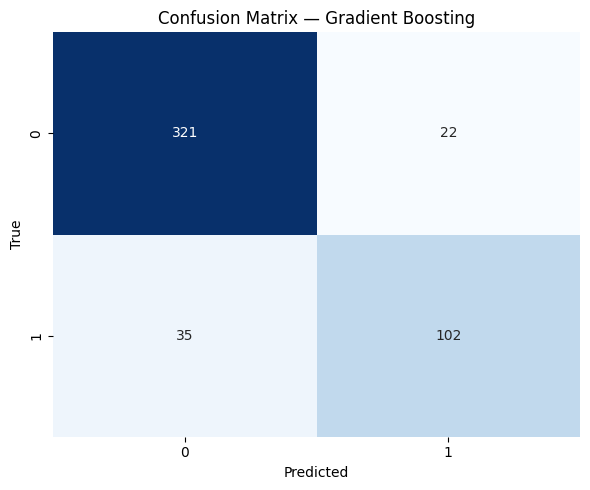

In [22]:
# ============================================================
# 📈 Evaluate Model (Auto-train if needed)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError
import joblib

# ============================================================
# 🧠 Choose model
# ------------------------------------------------------------
# Available options:
#   - "Random Forest"
#   - "Gradient Boosting"
#   - "Logistic Regression"
#   - "SVM (RBF)"
#   - "LightGBM"
#   - "XGBoost"
#   - "Neural Net" (not yet since it's not being fine tuned and thus can't be used)
# ============================================================

model_name = "Gradient Boosting"   # 🔄 Change this
model = models[model_name]

# --- Check if model is fitted
try:
    check_is_fitted(model)
    print(f"✅ Using already-trained model: {model_name}")
except NotFittedError:
    print(f"⚠️ Model '{model_name}' not fitted yet — training now...")
    model.fit(X_train, y_train)
    print(f"✅ {model_name} trained successfully!")

# --- Predict
y_pred = model.predict(X_test)

# --- Compute metrics
acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_class0 = f1_score(y_test, y_pred, pos_label=0)
f1_class1 = f1_score(y_test, y_pred, pos_label=1)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# --- Print summary
print(f"\n✅ Model Evaluation Summary ({model_name})")
print("=" * 60)
print(f"🔹 Accuracy:          {acc:.4f}")
print(f"🔹 Weighted F1-Score: {f1_weighted:.4f}")
print(f"🔹 F1 (class=0):      {f1_class0:.4f}")
print(f"🔹 F1 (class=1):      {f1_class1:.4f}")
print("\n🔹 Classification Report:\n", report)

# --- Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — {model_name}")
plt.tight_layout()
plt.show()


In [21]:
# ============================================================
# 📈 Save Model
# ============================================================

MODEL_PATH = f"../4. Models/{model_name.replace(' ', '_').lower()}_model.pkl"
joblib.dump(model, MODEL_PATH)
print(f"\n✅ Model saved to: {MODEL_PATH}")
print("=" * 60)


✅ Model saved to: ../4. Models/xgboost_model.pkl
